In [28]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Churn Prediction with Model Evaluation and Refinement") \
    .getOrCreate()

1. **Define Business Objectives:**
**Business Objective**: Predict customer churn to reduce attrition and increase retention strategies.
SMART Objective:
- Specific: Predict churn for customers who are likely to leave the service.
- Measurable: Improve churn prediction accuracy by at least 5%.
- Achievable: Using machine learning models to predict churn based on customer data.
- Relevant: Reducing churn helps retain customers and increases profitability.
- Time-bound: Achieve this improvement within the next 6 months.

In [30]:
# 2. **Big Data Collection and Preparation**
# Load Data
data = spark.read.csv("/content/Customer_Churn_Large_Dataset.csv", header=True, inferSchema=True)
data.show()

+-----------+-----------+--------------------------+-----------+------------------+----------+------------------+-----------+---------+---------------------------+----------------------+-----------------------+-------------------+------------------+-----+--------------+------+---+--------+------+-----+----------------------------+---------------------------------+--------------+--------------+------------------+------------------+--------------+------------+
|Customer ID|Churn Label|Account Length (in months)|Local Calls|        Local Mins|Intl Calls|         Intl Mins|Intl Active|Intl Plan|Extra International Charges|Customer Service Calls|Avg Monthly GB Download|Unlimited Data Plan|Extra Data Charges|State|  Phone Number|Gender|Age|Under 30|Senior|Group|Number of Customers in Group|Device Protection & Online Backup| Contract Type|Payment Method|    Monthly Charge|     Total Charges|Churn Category|Churn Reason|
+-----------+-----------+--------------------------+-----------+----------

In [38]:
# Load the dataset (example: CSV file)
df = spark.read.csv("/content/Customer_Churn_Large_Dataset.csv", header=True, inferSchema=True)

# Get dimensions
num_rows = df.count()
num_columns = len(df.columns)

print(f"The dataset has {num_rows} rows and {num_columns} columns.")


The dataset has 99965 rows and 29 columns.


In [39]:
# Handle Missing Values (Impute missing values with mean or mode for numerical/categorical features)
from pyspark.ml.feature import Imputer

imputer = Imputer(inputCols=["Total Charges", "Monthly Charge", "Account Length (in months)"],
                  outputCols=["Total Charges Imputed", "Monthly Charge Imputed", "Account Length Imputed"])
data = imputer.fit(data).transform(data)

In [41]:
# Handle Categorical Data (StringIndexer for Churn Label)
indexer = StringIndexer(inputCol="Churn Label", outputCol="Churn Label Index")
data = indexer.fit(data).transform(data)

In [42]:
# 3. **Feature Extraction and Engineering**
# Feature Selection using Correlation (for numerical features)
correlation_matrix = data.corr("Total Charges", "Monthly Charge")
print(f"Correlation between 'Total Charges' and 'Monthly Charge': {correlation_matrix}")

Correlation between 'Total Charges' and 'Monthly Charge': 0.0003581945086163011


In [43]:
# Assembling features
feature_columns = ["Total Charges Imputed", "Monthly Charge Imputed", "Account Length Imputed"]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
data = assembler.transform(data)

In [44]:
# Scaling Features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
data = scaler.fit(data).transform(data)

In [45]:
# Drop original columns that are not needed
data = data.drop("Churn Label")

In [46]:
# 4. **Data Partitioning for Spark**
# Partition the data into training, validation, and test sets
train_data, val_data, test_data = data.randomSplit([0.7, 0.2, 0.1], seed=42)

# Repartition data for better load balancing in Spark
train_data = train_data.repartition(5)  # Optimizing the number of partitions
val_data = val_data.repartition(5)
test_data = test_data.coalesce(1)  # Coalesce to reduce number of partitions for final test data

In [47]:
# 5. **Model Selection and Training**
# Logistic Regression Model
lr = LogisticRegression(featuresCol="scaled_features", labelCol="Churn Label Index", maxIter=10)
lr_model = lr.fit(train_data)

# Random Forest Classifier Model
rf = RandomForestClassifier(featuresCol="scaled_features", labelCol="Churn Label Index", numTrees=50)
rf_model = rf.fit(train_data)

# Hyperparameter Tuning for Random Forest
param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 50, 100]) \
    .addGrid(rf.maxDepth, [5, 10, 20]) \
    .build()

In [55]:
# Evaluator for Model Performance
evaluator = BinaryClassificationEvaluator(labelCol="Churn Label Index", metricName="areaUnderROC")

# CrossValidator for Hyperparameter Tuning
cross_val = CrossValidator(estimator=rf, estimatorParamMaps=param_grid,
                           evaluator=evaluator, numFolds=3)

# Fit the CrossValidator
cv_model = cross_val.fit(train_data)

# Best Random Forest Model
best_rf_model = cv_model.bestModel

# Print Best Hyperparameters
print(f"Best number of trees: {best_rf_model.getNumTrees}")
print(f"Best max depth: {best_rf_model.getOrDefault('maxDepth')}")

Best number of trees: 20
Best max depth: 5


In [58]:
from pyspark.ml.classification import RandomForestClassifier

# Define the classifier
rf = RandomForestClassifier(labelCol="Churn Label Index", featuresCol="scaled_features")

# Fit the model
model = rf.fit(data)

In [52]:
# # 4. CrossValidator for hyperparameter tuning
# cross_val = CrossValidator(estimator=rf,
#                            estimatorParamMaps=param_grid,
#                            evaluator=evaluator,
#                            numFolds=3)  # 3-fold cross-validation

In [59]:
# 6. **Model Evaluation and Refinement**
# Evaluate Logistic Regression Model
lr_predictions = lr_model.transform(val_data)
lr_evaluator = BinaryClassificationEvaluator(labelCol="Churn Label Index", metricName="areaUnderROC")
lr_auc = lr_evaluator.evaluate(lr_predictions)

# Evaluate Random Forest Model
rf_predictions = rf_model.transform(val_data)
rf_auc = lr_evaluator.evaluate(rf_predictions)

# Evaluate Best Random Forest Model (After Hyperparameter Tuning)
best_rf_predictions = best_rf_model.transform(val_data)
best_rf_auc = lr_evaluator.evaluate(best_rf_predictions)

# Print AUC Scores
print(f"Logistic Regression AUC: {lr_auc}")
print(f"Random Forest AUC: {rf_auc}")
print(f"Best Random Forest AUC (after tuning): {best_rf_auc}")


Logistic Regression AUC: 0.5000218888965691
Random Forest AUC: 0.5034994873390012
Best Random Forest AUC (after tuning): 0.5087785995714385


In [60]:
# Model Performance Evaluation: Accuracy, Precision, Recall, F1-Score
evaluator_accuracy = MulticlassClassificationEvaluator(labelCol="Churn Label Index", metricName="accuracy")
evaluator_precision = MulticlassClassificationEvaluator(labelCol="Churn Label Index", metricName="weightedPrecision")
evaluator_recall = MulticlassClassificationEvaluator(labelCol="Churn Label Index", metricName="weightedRecall")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="Churn Label Index", metricName="f1")

accuracy_lr = evaluator_accuracy.evaluate(lr_predictions)
precision_lr = evaluator_precision.evaluate(lr_predictions)
recall_lr = evaluator_recall.evaluate(lr_predictions)
f1_lr = evaluator_f1.evaluate(lr_predictions)

accuracy_rf = evaluator_accuracy.evaluate(rf_predictions)
precision_rf = evaluator_precision.evaluate(rf_predictions)
recall_rf = evaluator_recall.evaluate(rf_predictions)
f1_rf = evaluator_f1.evaluate(rf_predictions)

accuracy_best_rf = evaluator_accuracy.evaluate(best_rf_predictions)
precision_best_rf = evaluator_precision.evaluate(best_rf_predictions)
recall_best_rf = evaluator_recall.evaluate(best_rf_predictions)
f1_best_rf = evaluator_f1.evaluate(best_rf_predictions)

# Print detailed metrics
print(f"Logistic Regression Metrics: Accuracy={accuracy_lr}, Precision={precision_lr}, Recall={recall_lr}, F1-Score={f1_lr}")
print(f"Random Forest Metrics: Accuracy={accuracy_rf}, Precision={precision_rf}, Recall={recall_rf}, F1-Score={f1_rf}")
print(f"Best Random Forest Metrics: Accuracy={accuracy_best_rf}, Precision={precision_best_rf}, Recall={recall_best_rf}, F1-Score={f1_best_rf}")


Logistic Regression Metrics: Accuracy=0.4963777837402737, Precision=0.5009125141391249, Recall=0.49637778374027364, F1-Score=0.43716683020028324
Random Forest Metrics: Accuracy=0.4944995975315267, Precision=0.49710647136970704, Recall=0.4944995975315267, F1-Score=0.45472876326034756
Best Random Forest Metrics: Accuracy=0.5020123423665146, Precision=0.506810989841411, Recall=0.5020123423665146, F1-Score=0.4705281073936731


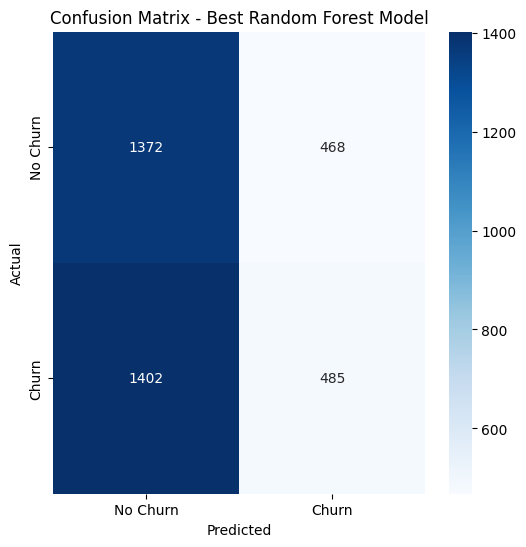

In [62]:
# 7. **Visualizations**
# Visualizing Confusion Matrix for Best Model (Random Forest)
from sklearn.metrics import confusion_matrix
import numpy as np

# Collect Predictions and Actual Values
y_true = best_rf_predictions.select("Churn Label Index").rdd.flatMap(lambda x: x).collect()
y_pred = best_rf_predictions.select("prediction").rdd.flatMap(lambda x: x).collect()

# Compute Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Random Forest Model")
plt.show()

# Plot ROC Curve for the Best Model
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

roc_data = best_rf_predictions.select("Churn Label Index", "probability")
roc_data = roc_data.withColumn("label", col("Churn Label Index"))
roc_data = roc_data.withColumn("prob", vector_to_array("probability").getItem(1))

In [66]:
# Stop Spark Session
spark.stop()